# Instructor dry run: will students see a real change after fine-tuning?

Run this **once, a few days before class**. For each of the five scenarios it measures, on **100** held-out test cases:

* the two baselines: **prompt only** and **prompt + policy docs**,
* **fine-tuned** accuracy at different amounts of clean and noisy training data (the student settings cards),
* how long training takes on your GPU.

It then tells you, per scenario, the **fewest training examples that give a clear improvement**, meaning the fine-tuned 95% range sits entirely above the baseline's range. Use that to set the default `N_EXAMPLES` and the settings cards.

| `MODE` | Fine-tuning runs per scenario | Rough time, 5 scenarios |
|---|---|---|
| `"quick"` | 100 clean, 100 noisy (cards B and D) | ~3 hours on a free T4 (measured, 3 Oct 2026) |
| `"full"` | 25 / 50 / 100 / 200 / 300 clean, 100 / 300 noisy | Not measured. Roughly 10 hours on a T4 by extrapolation, so use an L4 or A100 (Colab Pro) |

*The free tier cut the GPU off after about 5.5 hours in one session, so `"full"` will not finish on a free T4 in one go.* Results are saved after every run, so if Colab disconnects, re-run the cells and it continues where it stopped. The report prints the measured training speed.

## 1. Setup

Runtime → Change runtime type → **T4 GPU** (or L4 / A100 with Colab Pro), then run:

In [1]:
# Downloads the lab materials and installs two libraries (~1 minute)
REPO = "https://github.com/manaspandit27-web/manas.git"
BRANCH = "claude/nemotron-finetune-lab"
import os, sys
if not os.path.exists("/content/lab-repo"):
    !git clone -q --depth 1 -b {BRANCH} {REPO} /content/lab-repo
os.chdir("/content/lab-repo/nemotron-lab")
!pip install -q bitsandbytes peft
sys.path.insert(0, ".")
from lab import core
from IPython.display import Markdown, display
import pandas as pd
print("Ready. Scenarios:")
display(pd.DataFrame(core.list_scenarios()))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.5 MB/s eta 0:00:00
Ready. Scenarios:


             scenario                                              title  \
0  airline_complaints        Skyward Airways - Customer Complaint Triage   
1       claims_triage  Granite Shield Insurance - Auto Claims First N...   
2       expense_audit           Meridian Advisory - Expense Report Audit   
3      invoice_intake  Harvest Table Restaurant Group - Accounts Paya...   
4  lead_qualification       Lumen Analytics - Inbound Lead Qualification   

                        function  
0  Operations / Customer Service  
1    Risk / Insurance Operations  
2           Finance / Compliance  
3           Finance / Accounting  
4              Marketing / Sales  

In [2]:
# Options
MODE = "quick"          # "quick" or "full"
SCENARIOS = [s["scenario"] for s in core.list_scenarios()]   # or e.g. ["invoice_intake", "expense_audit"]
SAVE_TO_DRIVE = True    # keeps results if the Colab session ends (asks for Google Drive permission)

OUT = "dry_run_results.csv"
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT = "/content/drive/MyDrive/nemotron_dry_run_results.csv"
SETTINGS = core.QUICK_SWEEP if MODE == "quick" else core.FULL_SWEEP
print("Results file:", OUT)
print("Fine-tuning settings (examples, data, epochs):", SETTINGS)

Mounted at /content/drive
Results file: /content/drive/MyDrive/nemotron_dry_run_results.csv
Fine-tuning settings (examples, data, epochs): [(100, 'clean', 2), (100, 'noisy', 2)]


In [3]:
# Loads NVIDIA Nemotron onto the GPU (~3 minutes)
model, tok = core.load_model()

config.json:   0%|          | 0.00/910 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.6k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

## 2. Run everything (leave the tab open)

In [4]:
model, rows = core.sweep(model, tok, SCENARIOS, SETTINGS, n_test=100, out_csv=OUT)


=== airline_complaints: prompt


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Testing (prompt): [##############################] 100/100    

=== airline_complaints: prompt+docs
Testing (prompt+docs): [##############################] 100/100    

=== airline_complaints: fine-tune on 100 clean examples x 2 epoch(s)
Training 30.4M of 2.7B parameters (1.13%) on 100 clean examples for 2 epoch(s) = 50 steps
Fine-tuning: [##############################] 50/50 done in 11.3 min   
Testing (fine-tuned): [##############################] 100/100    

=== airline_complaints: fine-tune on 100 noisy examples x 2 epoch(s)
Training 30.4M of 2.7B parameters (1.13%) on 100 noisy examples for 2 epoch(s) = 50 steps
Fine-tuning: [##############################] 50/50 done in 11.4 min   
Testing (fine-tuned): [##############################] 100/100    

=== claims_triage: prompt
Testing (prompt): [##############################] 100/100    

=== claims_triage: prompt+docs
Testing (prompt+docs): [##############################] 100/100    

=== claims_triage: fine-tune on 100 clean e

## 3. Results

**How to read the recommendations:**

* *fewest examples: clearly beats prompt*: the smallest training set whose fine-tuned 95% range lies entirely above the prompt-only range. If this is **100 or less**, the default student setting (card B) will show a detectable change.
* *fewest examples: clearly beats prompt+docs*: the stronger test. Fine-tuning should beat pasting the policy into every prompt, too.
* **"not reached"** means no setting cleared the bar. Raise the default `N_EXAMPLES` (or `EPOCHS`) for that scenario, or don't assign it.

Copy the numbers into the *Dry-run results* table in `instructor/INSTRUCTOR-GUIDE.md`.

/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/c

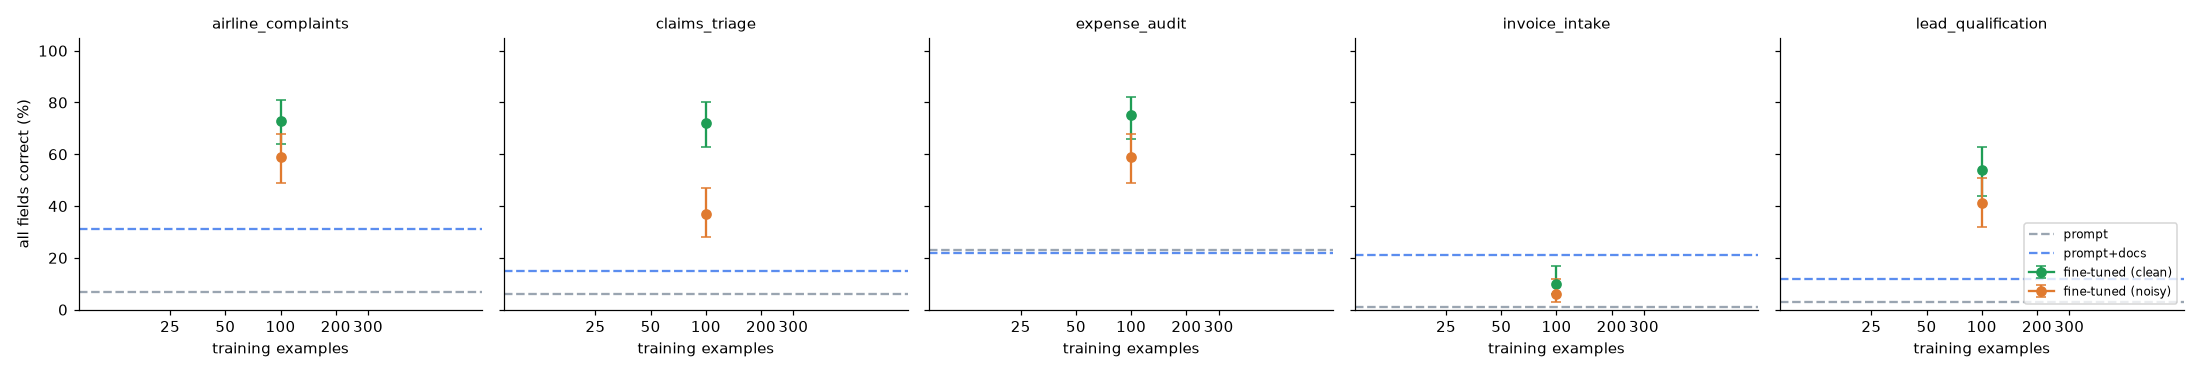

                   prompt prompt+docs  fewest examples: clearly beats prompt  scenario                                                                       
airline_complaints     7%         31%                                    100   
claims_triage          6%         15%                                    100   
expense_audit         23%         22%                                    100   
invoice_intake         1%         21%                                    100   
lead_qualification     3%         12%                                    100   

                   fewest examples: clearly beats prompt+docs  scenario                                                        
airline_complaints                                        100   
claims_triage                                             100   
expense_audit                                             100   
invoice_intake                                    not reached   
lead_qualification                                   

setting                  prompt  prompt+docs FT 100 clean x2 FT 100 noisy x2
scenario                                                                    
airline_complaints    7% (3-14)  31% (23-41)     73% (64-81)     59% (49-68)
claims_triage         6% (3-12)   15% (9-23)     72% (63-80)     37% (28-47)
expense_audit       23% (16-32)  22% (15-31)     75% (66-82)     59% (49-68)
invoice_intake         1% (0-5)  21% (14-30)      10% (6-17)       6% (3-12)
lead_qualification     3% (1-8)   12% (7-20)     54% (44-63)     41% (32-51)

In [5]:
table, recs = core.sweep_report(OUT)
display(recs)
display(table)

In [ ]:
# Download the raw results (one row per run, including per-field accuracy)
from google.colab import files
files.download(OUT)

## 4. Optional: more examples for invoice_intake, and fine-tuned + docs

Run this after sections 1-3 if `invoice_intake` reports **"not reached"**. It fine-tunes that scenario on more examples (200 and 300), then on the card B and card D settings, and tests every fine-tuned model twice on the same 100 held-out cases:

* **fine-tuned**: the normal prompt (no policy), as in section 2,
* **fine-tuned+docs**: the same fine-tuned model with the policy pasted into the prompt.

Allow about 2 hours on a T4. Results go to a separate file, `nemotron_ft_plus_docs_results.csv`, and the cell resumes if re-run. It needs `SAVE_TO_DRIVE = True`.

In [6]:
# Extra experiment on invoice_intake: more training examples, and every fine-tuned model is tested twice:
# with the normal prompt ("fine-tuned") and with the policy docs pasted into the prompt ("fine-tuned+docs").
# Results are appended after every test, so re-running this cell resumes where it stopped.
import csv, os, time
OUT2 = "/content/drive/MyDrive/nemotron_ft_plus_docs_results.csv"
# 200 and 300 clean examples first; then the original card B / card D settings (100 clean, 100 noisy).
PLAN = [("invoice_intake", 200, "clean", 2), ("invoice_intake", 300, "clean", 2),
        ("invoice_intake", 100, "clean", 2), ("invoice_intake", 100, "noisy", 2)]

def _done():
    if not os.path.exists(OUT2):
        return set()
    with open(OUT2, newline="", encoding="utf-8") as fh:
        return {(r["scenario"], r["method"], r["examples"], r["data"], r["epochs"]) for r in csv.DictReader(fh)}

def _save(row):
    new = not os.path.exists(OUT2)
    with open(OUT2, "a", newline="", encoding="utf-8") as fh:
        w = csv.DictWriter(fh, fieldnames=core.SWEEP_COLUMNS)
        if new:
            w.writeheader()
        w.writerow(row)

for key, n, data, epochs in PLAN:
    done = _done()
    need = [m for m in ("fine-tuned", "fine-tuned+docs") if (key, m, str(n), data, str(epochs)) not in done]
    if not need:
        continue
    scn = core.load_scenario(key)
    print(f"\n=== {key}: fine-tune on {n} {data} examples x {epochs} epoch(s)")
    t0 = time.time()
    model, losses = core.train(model, tok, scn, n_examples=n, data=data, epochs=epochs)
    minutes = round((time.time() - t0) / 60, 1)
    loss = round(sum(losses[-5:]) / len(losses[-5:]), 4)
    for m in need:
        res = core.evaluate(model, tok, scn, "prompt+docs" if m == "fine-tuned+docs" else "fine-tuned", n=100)
        _save(core._sweep_row(scn, res, m, n, data, epochs, minutes, loss))
        s = res["summary"]
        print(f"RESULT {key} | {m} | {n} {data} | {s['all fields correct %']}% ({s['95% range']})")
print("\nALL DONE")


=== invoice_intake: fine-tune on 200 clean examples x 2 epoch(s)
Training 30.4M of 2.7B parameters (1.13%) on 200 clean examples for 2 epoch(s) = 100 steps
Fine-tuning: [##############################] 100/100 done in 25.0 min   
Testing (fine-tuned): [##############################] 100/100    
RESULT invoice_intake | fine-tuned | 200 clean | 38% (29-48%)
Testing (prompt+docs): [##############################] 100/100    
RESULT invoice_intake | fine-tuned+docs | 200 clean | 37% (28-47%)

=== invoice_intake: fine-tune on 300 clean examples x 2 epoch(s)
Training 30.4M of 2.7B parameters (1.13%) on 300 clean examples for 2 epoch(s) = 150 steps
Fine-tuning: [##############################] 150/150 done in 37.9 min   
Testing (fine-tuned): [##############################] 100/100    
RESULT invoice_intake | fine-tuned | 300 clean | 57% (47-66%)
Testing (prompt+docs): [##############################] 100/100    
RESULT invoice_intake | fine-tuned+docs | 300 clean | 38% (29-48%)

=== invoi